In [55]:
import os
import sys

import pickle
import torch
import torch.multiprocessing as mp
from torch.utils.data import DataLoader

# Add the repo root (e.g.,/fairmast-data-preprocessing) to sys.path
REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in globals()
                                         else os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print(f"REPO_ROOT: {REPO_ROOT}")

from scripts.MAST_tools.MAST_dataset import MastDataset
from scripts.main_pipeline.utils.utils import read_data_split_csv, flatten_then_collate
from scripts.main_pipeline.preprocessing.sampled_shot_list import yamane_sampled_shot_list
from scripts.main_pipeline.preprocessing.standardscaling_preprocessing import get_mean_shot, get_std_shot
from scripts.main_pipeline.utils.utils import ComposeTransforms
from scripts.main_pipeline.transforms.signal_level_transforms.pretrained_stdscale_normalize_transform import(
    StdScalingTransform
)
from scripts.main_pipeline.transforms.signal_level_transforms.sampling_reference_time_transform import (
    SamplingToReferenceTimeTransform
)
from scripts.main_pipeline.transforms.shot_level_transforms.truncation_transform import (
    TruncationTransform
)
from scripts.main_pipeline.transforms.shot_level_transforms.window_segmenter_transform import (
    WindowSegmenterTransform
)
from scripts.main_pipeline.transforms.shot_level_transforms.drop_sample_with_nans import (
    DropSampleWithNans
)
from scripts.main_pipeline.transforms.signal_level_transforms.fill_profile_with_zeros_imputer_transform import (
    FillProfileWithZerosTransform
)
from scripts.main_pipeline.transforms.signal_level_transforms.fill_with_zeros_imputer_transform import (
    FillWithZerosImputerTransform
)

from scripts.main_pipeline.transforms.shot_level_transforms.cnn_transform import CNNTransform
from scripts.main_pipeline.models.cnn_model import MultiBranchCNNModel
from multiprocessing import cpu_count

print(f"\nNumber of Cores: {cpu_count()}\n")

# ----------------------------------------------------------------------------------------------------------------------
# Determine device to train on

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

REPO_ROOT: /Users/cecilerousseau/Documents/AD Fusion UKI/fairmast-data-preprocessing

Number of Cores: 16



In [56]:
# ----------------------------------------------------------------------------------------------------------------------
def get_train_test_val_shots(max_index=None):
    train_sh, test_sh, val_sh = read_data_split_csv()

    if max_index:
        train_sh = train_sh[0:max_index]
        val_sh = val_sh[0:max_index]
        test_sh = test_sh[0:max_index]

    return train_sh, test_sh, val_sh

In [57]:
# ----------------------------------------------------------------------------------------------------------------------
# def fit_mean_and_std_for_signal_transform(output_sub_dir, verbose=False):

#     if verbose:
#         print('\n\n----------TRANSFORM FITTING----------\n')

#     preprocessing_train_dataset = MastDataset(
#         local=LOCAL_FLAG,
#         shots_list=yamane_sampled_shot_list(train_shots, error=0.05),
#         source_signal_list=source_signal_list,
#         signal_level_transform_map=None,
#         shot_level_transform=None
#     )

#     if verbose:
#         print(f"len(preprocessing_train_dataset): {len(preprocessing_train_dataset)}")

#     dict_mean_ = get_mean_shot(preprocessing_train_dataset)
#     dict_std_ = get_std_shot(preprocessing_train_dataset)

#     # Save dict_mean and dict_std used!

#     output_dir = os.path.join("output", output_sub_dir)
#     os.makedirs(output_dir, exist_ok=True)
#     if verbose:
#         print(f"Output folder to save fitted mean and std dicts: {output_dir}")

#     with open(output_dir + 'dict_mean_shot.pkl', 'wb') as f:
#         pickle.dump(dict_mean_, f)
#     with open(output_dir + 'dict_std_shot.pkl', 'wb') as f:
#         pickle.dump(dict_std_, f)

#     return dict_mean_, dict_std_


# ----------------------------------------------------------------------------------------------------------------------
def initialize_datasets(
        sources_and_signals,
        shots,
        sig_tran_map,
        shot_tran,
        local_flag=False,
        verbose=False

):

    datasets_ = {"train": None, "val": None, "test": None}

    # ..................................................................................................................
    # Train

    if shots["train"]:
        datasets_["train"] = MastDataset(
            local=local_flag,
            shots_list=shots["train"],
            source_signal_list=sources_and_signals,
            signal_level_transform_map=sig_tran_map,
            shot_level_transform=shot_tran
        )
        if verbose:
            print(f"len(mast_train_dataset): {len(datasets_['train'])}")

    # ..................................................................................................................
    # Val

    if shots["val"]:
        datasets_["val"] = MastDataset(
            local=local_flag,
            shots_list=shots["val"],
            source_signal_list=sources_and_signals,
            signal_level_transform_map=sig_tran_map,
            shot_level_transform=shot_tran
        )
        if verbose:
            print(f"len(val_dataset): {len(datasets_['val'])}")

    # ..................................................................................................................
    # Test

    if shots["test"]:
        datasets_["test"] = MastDataset(
            local=local_flag,
            shots_list=shots["test"],
            source_signal_list=sources_and_signals,
            signal_level_transform_map=sig_tran_map,
            shot_level_transform=shot_tran
        )
        if verbose:
            print(f"len(test_dataset): {len(datasets_['test'])}")

    # ..................................................................................................................
    # Return

    return datasets_


# ----------------------------------------------------------------------------------------------------------------------
def initialize_dataloaders(
        datasets,
        collate_function,
        batch_size,
        num_workers,
        shuffle=True,
        drop_last=False,
        verbose=False
):

    dataloaders_ = {"train": None, "val": None, "test": None}

    if verbose:
        print('\n\n----------DATASET & DATALOADER INITIALIZATION----------\n')

    # ..................................................................................................................
    # Train

    if datasets["train"]:
        dataloaders_["train"] = DataLoader(
            dataset=datasets["train"],
            batch_size=batch_size,
            # batch_size=len(datasets['train']),
            num_workers=num_workers,
            shuffle=shuffle,
            drop_last=drop_last,
            collate_fn=collate_function
        )

    # ..................................................................................................................
    # Val

    if datasets["val"]:
        dataloaders_["val"] = DataLoader(
            dataset=datasets["val"],
            batch_size=batch_size,
            # batch_size=len(datasets["val"]),
            num_workers=num_workers,
            shuffle=shuffle,
            drop_last=drop_last,
            collate_fn=collate_function
        )

    # ..................................................................................................................
    # Test

    if datasets["test"]:
        dataloaders_["test"] = DataLoader(
            dataset=datasets["test"],
            batch_size=batch_size,
            # batch_size=len(datasets["test"]),
            num_workers=num_workers,
            shuffle=shuffle,
            drop_last=drop_last,
            collate_fn=collate_function
        )

    # ..................................................................................................................
    # Return

    return dataloaders_


# ----------------------------------------------------------------------------------------------------------------------
def create_cnn_architecture(
        train_dataloader_,
        verbose=False
):

    if verbose:
        print("\n\n----------MODEL INITIALIZATION----------\n")

    input_shapes = [arr.shape for arr in train_dataloader_.dataset[0][0][0]]
    if verbose:
        print(f"input_shapes: {input_shapes}")

    output_shape = [arr.shape for arr in train_dataloader_.dataset[0][0][1]]
    if verbose:
        print(f"output_shape: {output_shape}")

    return MultiBranchCNNModel(input_shapes, output_shape).to(device)


# ----------------------------------------------------------------------------------------------------------------------
def loop_for_cnn_training(
        base_cnn_model,
        lr,
        best_val_loss,
        loss_criterion,
        patience,
        output_sub_dir,
        verbose=False

):

    if verbose:
        print('\n\n----------CNN TRAINING----------\n')

    output_dir = os.path.join("output", output_sub_dir)
    os.makedirs(output_dir, exist_ok=True)
    if verbose:
        print(f"Output folder to save trained model: {output_dir}")

    optimizer = torch.optim.Adam(base_cnn_model.parameters(), lr=lr)

    best_model_state_ = None
    early_stop_ = False
    epochs_no_improve = 0
    for epoch in range(MAX_EPOCHS):
        base_cnn_model.train()
        running_loss = 0.0
        num_batches = 0

        if verbose:
            print(f'\nEpoch {epoch+1}\n')

        for batch_idx, (x_train, y_train) in enumerate(train_dataloader):

            x_train = [arr.to(torch.float32).to(device) for arr in x_train]
            # print([arr.shape for arr in x_train])
            # print(y_train.min().item(), y_train.max().item())

            y_train = y_train[0].to(torch.float32).to(device)
            if verbose:
                # print(y_train.shape)
                print(f'Batch {batch_idx} size is {len(y_train)}')

            outputs_ = base_cnn_model(*x_train).squeeze()
            loss_ = loss_criterion(outputs_, y_train)
            if verbose:
                # print(f"outputs' shape: {outputs_.shape}")
                print(f'Batch loss: {loss_}')

            optimizer.zero_grad()
            loss_.backward()
            optimizer.step()

            running_loss += loss_.item()
            num_batches += len(y_train)
            if verbose:
                print(f'Actual num_batches is {num_batches}')

        avg_loss = running_loss / num_batches
        # print(f"Epoch [{epoch+1}/{MAX_EPOCHS}], Average Loss: {avg_loss:.4f}")

        # Validation phase & Early stopping check

        base_cnn_model.eval()
        val_running_loss = 0.0
        val_batches = 0

        with torch.no_grad():
            for x_val, y_val in val_dataloader:
                x_val = [arr.to(torch.float32).to(device) for arr in x_val]
                y_val = y_val[0].to(torch.float32).to(device)

                val_outputs = base_cnn_model(*x_val).squeeze()
                val_loss = loss_criterion(val_outputs, y_val)

                val_running_loss += val_loss.item()
                val_batches += len(y_val)

        avg_val_loss = val_running_loss / val_batches
        if verbose:
            print(f"Epoch [{epoch+1}/{MAX_EPOCHS}], Average Loss: {avg_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state_ = base_cnn_model.state_dict()

            # Save best model state
            torch.save(best_model_state_, output_dir + "best_model.pt")

        else:
            epochs_no_improve += 1
            if verbose:
                print(f"No improvement for {epochs_no_improve} epochs.")
            if epochs_no_improve >= patience:
                early_stop_ = True
                if verbose:
                    print("Early stopping triggered.")
                break

    return best_model_state_, early_stop_

In [58]:
LOCAL_FLAG = False
mp.set_start_method("spawn", force=True)

# ..................................................................................................................
# For common pipeline

SUBSET_OF_SHOTS = 10  # <- This can be None for the entire dataset, or a small integer.
OUTPUT_SUB_FOLDER = 'cnn_output/'  # <- Sub-folder within /output/
BATCH_SIZE = 500  # 500
NUM_WORKERS = 64  # 64
MAX_EPOCHS = 500

REF_FREQ = 0.005

source_signal_list = [
    ('magnetics', 'flux_loop_flux'),
    ('magnetics', 'b_field_pol_probe_ccbv_field'),
    ('magnetics', 'b_field_pol_probe_obr_field'),
    ('magnetics', 'b_field_pol_probe_obv_field'),
    ('pf_active', 'solenoid_current'),
    ('pf_active', 'coil_voltage'),
    ('pf_active', 'coil_current'),
    ('pulse_schedule', 'i_plasma'),
    ('summary', 'power_nbi'),
    ('equilibrium', 'elongation'),
    ('equilibrium', 'elongation_axis'),
    ('equilibrium', 'triangularity_upper'),
    ('equilibrium', 'triangularity_lower'),
    ('equilibrium', 'minor_radius'),
    ('equilibrium', 'magnetic_axis_r'),
    ('equilibrium', 'magnetic_axis_z')
]

# ..................................................................................................................
# For CNN pipeline

PARAMETERS_WINDOWS_SEGMENTER = {
    'x_keys': [
        'magnetics-flux_loop_flux',
        'magnetics-b_field_pol_probe_ccbv_field',
        'magnetics-b_field_pol_probe_obr_field',
        'magnetics-b_field_pol_probe_obv_field',
        'pf_active-solenoid_current',
        'pf_active-coil_voltage',
        'pf_active-coil_current',
        'pulse_schedule-i_plasma',
        'summary-power_nbi',
    ],
    'y_keys': [
        'equilibrium-elongation',
        'equilibrium-elongation_axis',
        'equilibrium-triangularity_upper',
        'equilibrium-triangularity_lower',
        'equilibrium-minor_radius',
        'equilibrium-magnetic_axis_r',
        'equilibrium-magnetic_axis_z',
    ],
    'x_window_sec': 0,
    'y_window_sec': 0,
    'dt_sec': 0.025,
    'stride_sec': None,
    'stride_unitary': True,
    'min_samples_per_window': 1,
    'verbose': False,
}


In [59]:
# Create sets of shot IDs for training, validation and testing
train_shots, test_shots, val_shots = get_train_test_val_shots(
    max_index=SUBSET_OF_SHOTS
)

# Fit mean and std for signal transformation
# dict_mean, dict_std = fit_mean_and_std_for_signal_transform(
#     output_sub_dir=OUTPUT_SUB_FOLDER,
#     verbose=True
# )

with open('/Users/cecilerousseau/Documents/AD Fusion UKI/fairmast-data-preprocessing/output/cnn_output/dict_mean_shot.pkl', 'rb') as f:
    dict_mean = pickle.load(f)
with open('/Users/cecilerousseau/Documents/AD Fusion UKI/fairmast-data-preprocessing/output/cnn_output/dict_std_shot.pkl', 'rb') as f:
    dict_std = pickle.load(f)

# Get the user-defined composite signal transform map
signal_transform_map = {var: ComposeTransforms([
        FillProfileWithZerosTransform(),
        StdScalingTransform(dict_mean[var], dict_std[var]),
        FillWithZerosImputerTransform(),
        SamplingToReferenceTimeTransform(REF_FREQ),
])
    for var in [f'{source}-{signal}' for source, signal in source_signal_list]
}

# ..................................................................................................................
# For CNN pipeline

shot_transform = ComposeTransforms([  # shape-consistent transform
    TruncationTransform(),
    # WindowSegmenterTransform(**PARAMETERS_WINDOWS_SEGMENTER),  # shape-modifying transform
    # DropSampleWithNans(),
    # CNNTransform()  # shape-modifying transform
    ])

# Prepare datasets
datasets_train_val_test = initialize_datasets(
    sources_and_signals=source_signal_list,
    shots={"train": train_shots, "val": val_shots, "test": test_shots},
    sig_tran_map=signal_transform_map,
    shot_tran=shot_transform,
    local_flag=LOCAL_FLAG,
    verbose=True
)


/Users/cecilerousseau/Documents/AD Fusion UKI/fairmast-data-preprocessing/metadata/2025-05-12/data_splits.csv
len(mast_train_dataset): 10
len(val_dataset): 10
len(test_dataset): 10


In [60]:
train_data_dict = datasets_train_val_test['train']

In [61]:
example_shot = train_data_dict[0]

In [64]:
example_shot['equilibrium-magnetic_axis_z']['values'].shape

(1, 109)

In [66]:
fft_list

[]

In [74]:
example_shot['equilibrium-magnetic_axis_z']['values'].shape[1]

109

In [79]:
min_win

10

In [80]:
max_len

1

In [83]:
T

109

In [87]:
len(t)

50

10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105


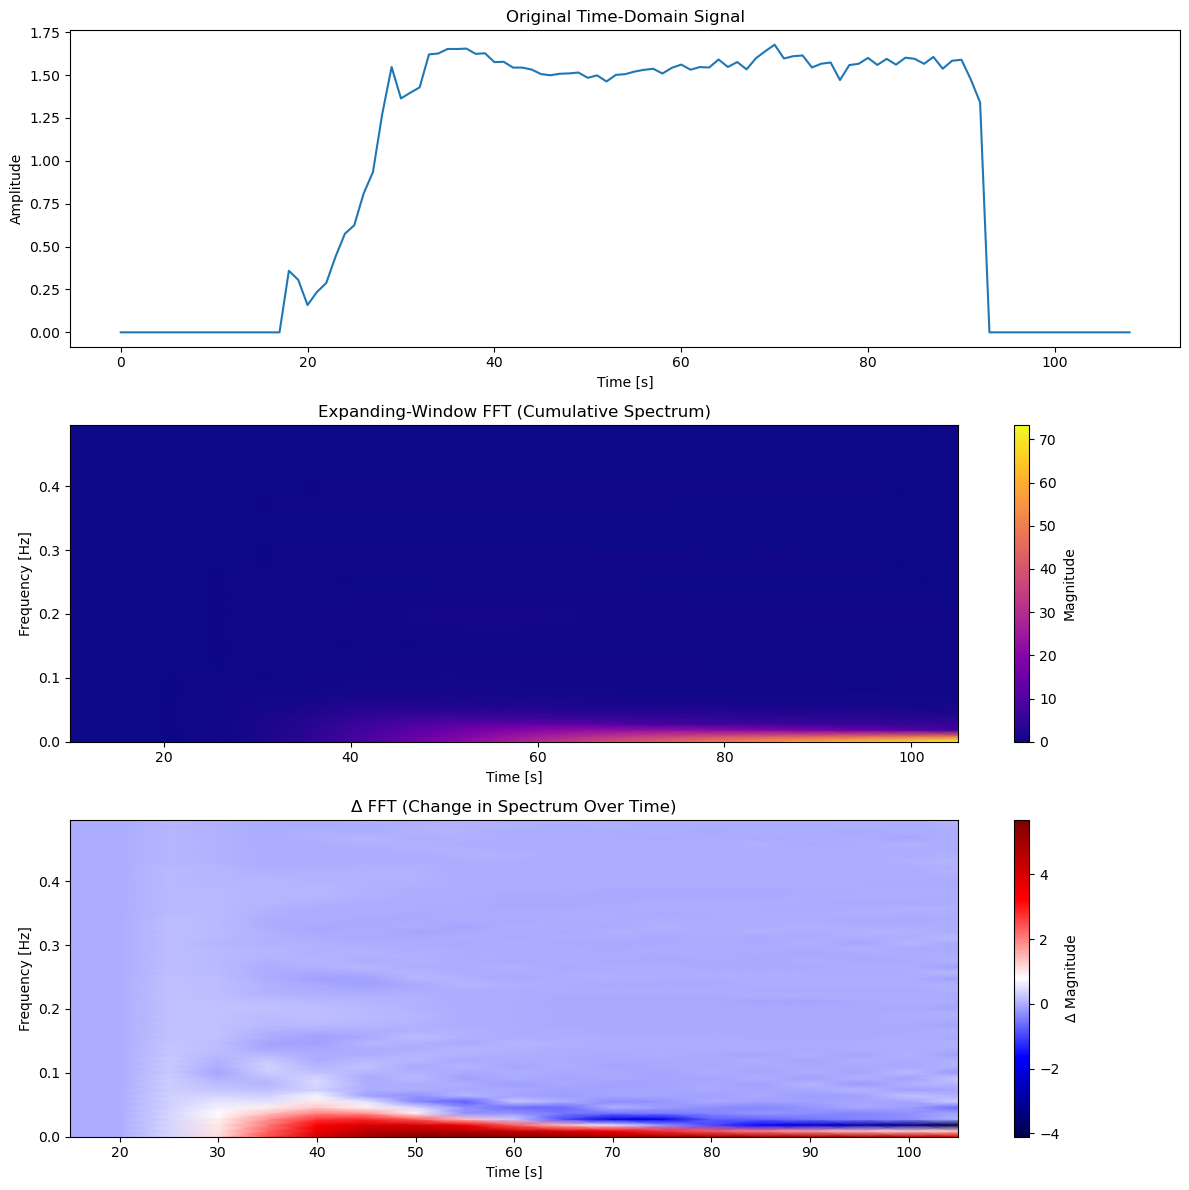

In [89]:
# Construct complex time-varying signal
signal = example_shot['equilibrium-magnetic_axis_z']['values']

import numpy as np
import matplotlib.pyplot as plt

# --- Generate synthetic signal ---
T = len( example_shot['equilibrium-magnetic_axis_z']['values'][0] )
t = [k for k in range(T)]

# Construct complex time-varying signal
signal = example_shot['equilibrium-magnetic_axis_z']['values'][0]

# --- Expanding FFT settings ---
min_win = 10  # start at 100 ms
step = 5    # grow by 50 ms each step
max_len = len(signal)
fs=1

fft_list = []
freqs_list = []
times = []

for end in range(min_win, max_len, step):
    print(end)
    segment = signal[:end] * np.hanning(end)
    fft_vals = np.abs(np.fft.rfft(segment))
    fft_freqs = np.fft.rfftfreq(end, 1/1)

    fft_list.append(fft_vals)
    freqs_list.append(fft_freqs)
    times.append(end / 1)

# Interpolate to uniform frequency axis for plotting
max_len_freq = max(len(f) for f in fft_list)
uniform_freqs = np.fft.rfftfreq(max_len, 1/fs)
interp_spectrogram = []

for fft_vals, f in zip(fft_list, freqs_list):
    interp = np.interp(uniform_freqs, f, fft_vals)
    interp_spectrogram.append(interp)

interp_spectrogram = np.array(interp_spectrogram).T  # shape: [freqs x time]

# Compute delta between FFTs across time (difference along columns)
delta_spectrogram = np.diff(interp_spectrogram, axis=1)
delta_times = times[1:]  # since diff drops one time step



# 3. Plot delta of expanding FFTs
fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: Original signal
axs[0].plot(t, signal)
axs[0].set_title("Original Time-Domain Signal")
axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel("Amplitude")

# Plot 2: Expanding FFT
pcm1 = axs[1].pcolormesh(times, uniform_freqs, interp_spectrogram, shading='gouraud', cmap='plasma')
axs[1].set_title("Expanding-Window FFT (Cumulative Spectrum)")
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("Frequency [Hz]")
axs[1].set_ylim(0,)
fig.colorbar(pcm1, ax=axs[1], label='Magnitude')

# Plot 3: Delta of expanding FFT
pcm2 = axs[2].pcolormesh(delta_times, uniform_freqs, delta_spectrogram, shading='gouraud', cmap='seismic')
axs[2].set_title("Δ FFT (Change in Spectrum Over Time)")
axs[2].set_xlabel("Time [s]")
axs[2].set_ylabel("Frequency [Hz]")
axs[2].set_ylim(0,)
fig.colorbar(pcm2, ax=axs[2], label='Δ Magnitude')

plt.tight_layout()
plt.show()



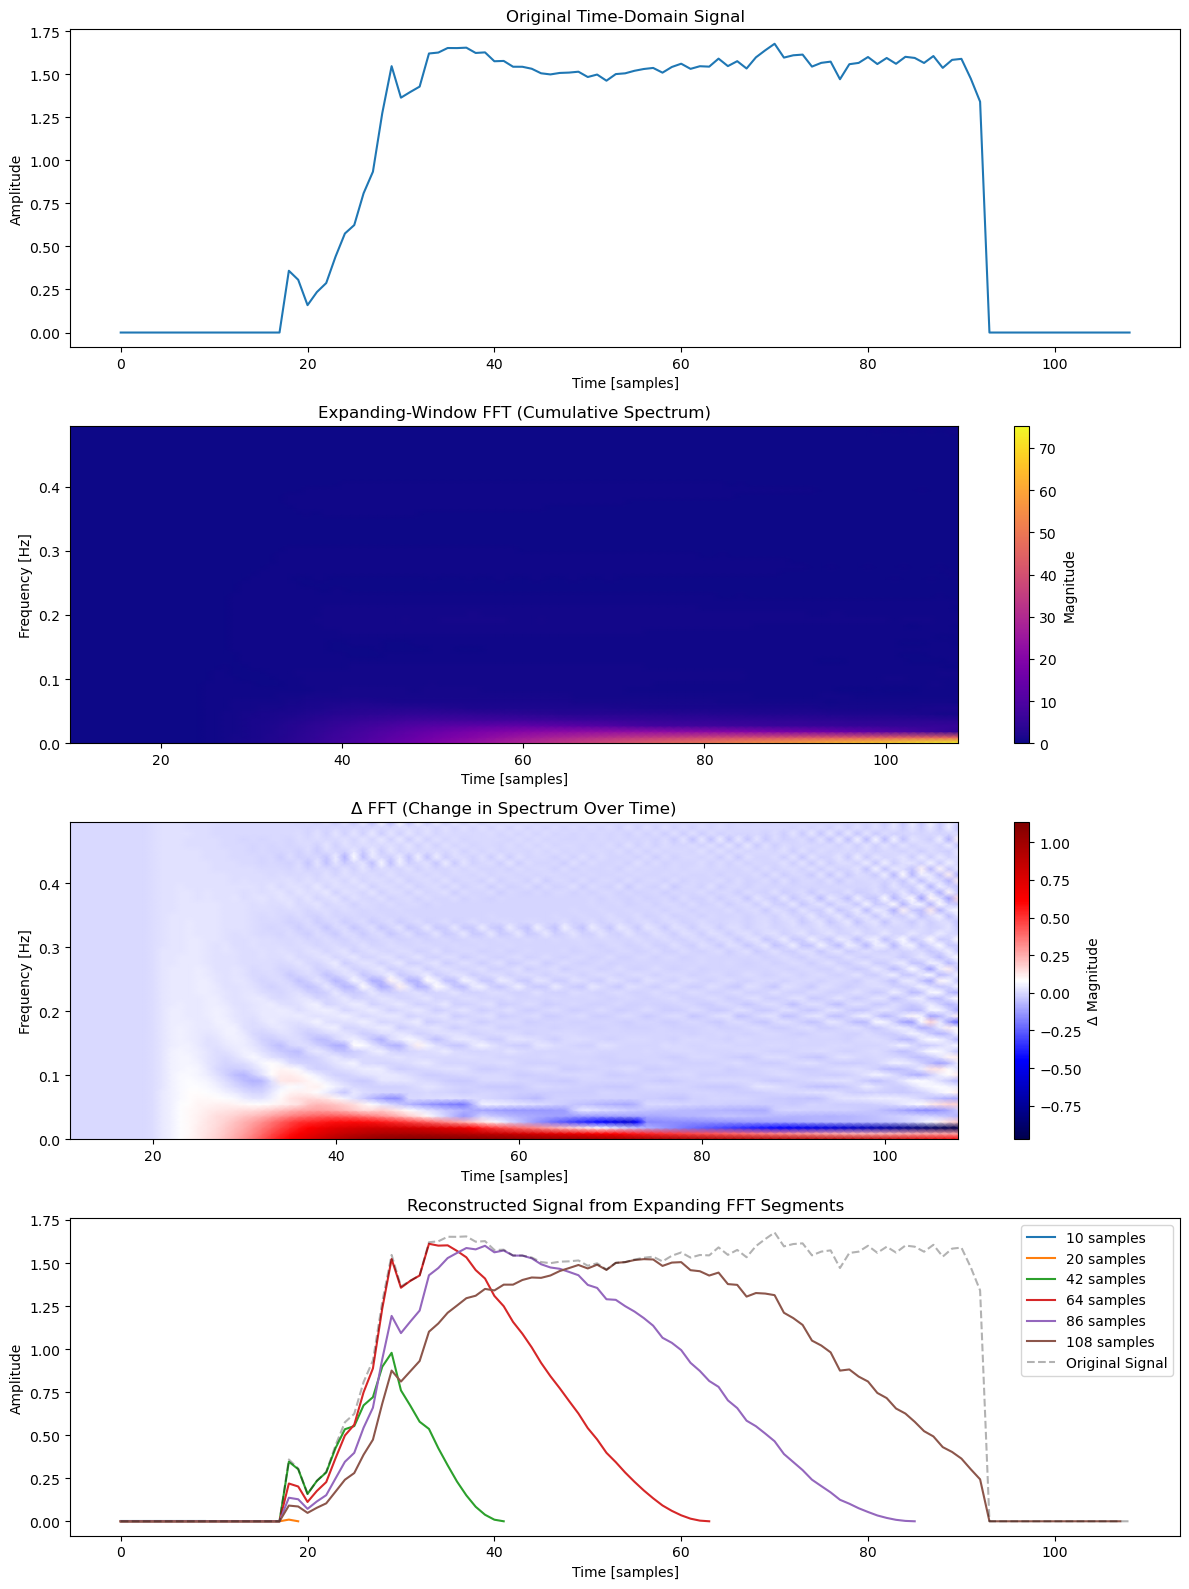

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# --- Extract signal from shot ---
signal = example_shot['equilibrium-magnetic_axis_z']['values'][0]
T = len(signal)
t = np.arange(T)

# --- Expanding FFT settings ---
min_win = 10   # samples
step = 1     # samples
max_len = len(signal)
fs = 1         # sample rate in Hz (set to 1 since sample spacing is 1 unit)

fft_list = []
freqs_list = []
times = []
reconstructed_signals = []

for end in range(min_win, max_len, step):
    segment = signal[:end] * np.hanning(end)
    fft_vals = np.fft.rfft(segment)
    fft_freqs = np.fft.rfftfreq(end, 1/fs)

    fft_list.append(np.abs(fft_vals))
    freqs_list.append(fft_freqs)
    times.append(end / fs)

    # --- Reconstruction via inverse FFT ---
    recon_segment = np.fft.irfft(fft_vals)
    reconstructed_signals.append(recon_segment)

# --- Interpolate FFTs to uniform frequency grid ---
uniform_freqs = np.fft.rfftfreq(max_len, 1/fs)
interp_spectrogram = []

for fft_vals, f in zip(fft_list, freqs_list):
    interp = np.interp(uniform_freqs, f, fft_vals)
    interp_spectrogram.append(interp)

interp_spectrogram = np.array(interp_spectrogram).T  # [freqs x time]

# --- Compute delta FFT ---
delta_spectrogram = np.diff(interp_spectrogram, axis=1)
delta_times = times[1:]

# --- Plotting ---
fig, axs = plt.subplots(4, 1, figsize=(12, 16))

# Plot 1: Original signal
axs[0].plot(t, signal)
axs[0].set_title("Original Time-Domain Signal")
axs[0].set_xlabel("Time [samples]")
axs[0].set_ylabel("Amplitude")

# Plot 2: Expanding FFT
pcm1 = axs[1].pcolormesh(times, uniform_freqs, interp_spectrogram, shading='gouraud', cmap='plasma')
axs[1].set_title("Expanding-Window FFT (Cumulative Spectrum)")
axs[1].set_xlabel("Time [samples]")
axs[1].set_ylabel("Frequency [Hz]")
axs[1].set_ylim(0, )
fig.colorbar(pcm1, ax=axs[1], label='Magnitude')

# Plot 3: Delta of FFT
pcm2 = axs[2].pcolormesh(delta_times, uniform_freqs, delta_spectrogram, shading='gouraud', cmap='seismic')
axs[2].set_title("Δ FFT (Change in Spectrum Over Time)")
axs[2].set_xlabel("Time [samples]")
axs[2].set_ylabel("Frequency [Hz]")
axs[2].set_ylim(0, )
fig.colorbar(pcm2, ax=axs[2], label='Δ Magnitude')

# Plot 4: Reconstructed signal segments
plot_indices = np.linspace(0, len(reconstructed_signals) - 1, 10).astype(int)
for idx in plot_indices:
    try :
        end = min_win + idx * step
        recon_t = t[:end]
        axs[3].plot(recon_t, reconstructed_signals[idx], label=f'{end} samples')
    except:
        continue

# Overlay original signal (dashed) for reference
axs[3].plot(t, signal, 'k--', alpha=0.3, label='Original Signal')
axs[3].set_title("Reconstructed Signal from Expanding FFT Segments")
axs[3].set_xlabel("Time [samples]")
axs[3].set_ylabel("Amplitude")
axs[3].legend()

plt.tight_layout()
plt.show()


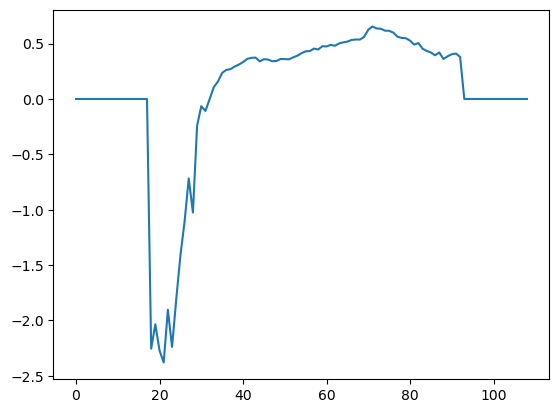

In [104]:
plt.plot(signal)

/Users/cecilerousseau/miniforge3/envs/fairmast-data-preprocessing/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/cecilerousseau/miniforge3/envs/fairmast-data-preprocessing/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


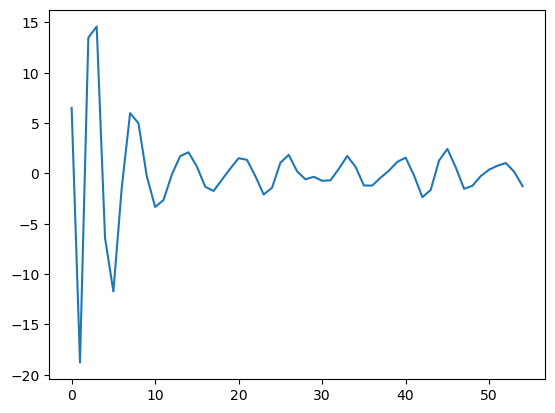

In [102]:
plt.plot( np.fft.rfft(signal) )

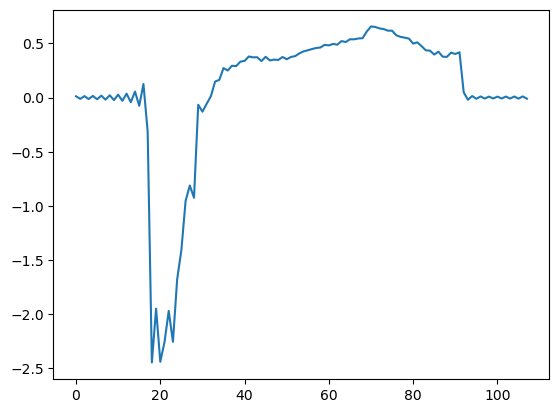

In [106]:
plt.plot( np.fft.irfft ( np.fft.rfft(signal), n=len(signal)-1) )

In [107]:
[arr.shape for arr in reconstructed_signals]

[(10,),
 (10,),
 (12,),
 (12,),
 (14,),
 (14,),
 (16,),
 (16,),
 (18,),
 (18,),
 (20,),
 (20,),
 (22,),
 (22,),
 (24,),
 (24,),
 (26,),
 (26,),
 (28,),
 (28,),
 (30,),
 (30,),
 (32,),
 (32,),
 (34,),
 (34,),
 (36,),
 (36,),
 (38,),
 (38,),
 (40,),
 (40,),
 (42,),
 (42,),
 (44,),
 (44,),
 (46,),
 (46,),
 (48,),
 (48,),
 (50,),
 (50,),
 (52,),
 (52,),
 (54,),
 (54,),
 (56,),
 (56,),
 (58,),
 (58,),
 (60,),
 (60,),
 (62,),
 (62,),
 (64,),
 (64,),
 (66,),
 (66,),
 (68,),
 (68,),
 (70,),
 (70,),
 (72,),
 (72,),
 (74,),
 (74,),
 (76,),
 (76,),
 (78,),
 (78,),
 (80,),
 (80,),
 (82,),
 (82,),
 (84,),
 (84,),
 (86,),
 (86,),
 (88,),
 (88,),
 (90,),
 (90,),
 (92,),
 (92,),
 (94,),
 (94,),
 (96,),
 (96,),
 (98,),
 (98,),
 (100,),
 (100,),
 (102,),
 (102,),
 (104,),
 (104,),
 (106,),
 (106,),
 (108,)]

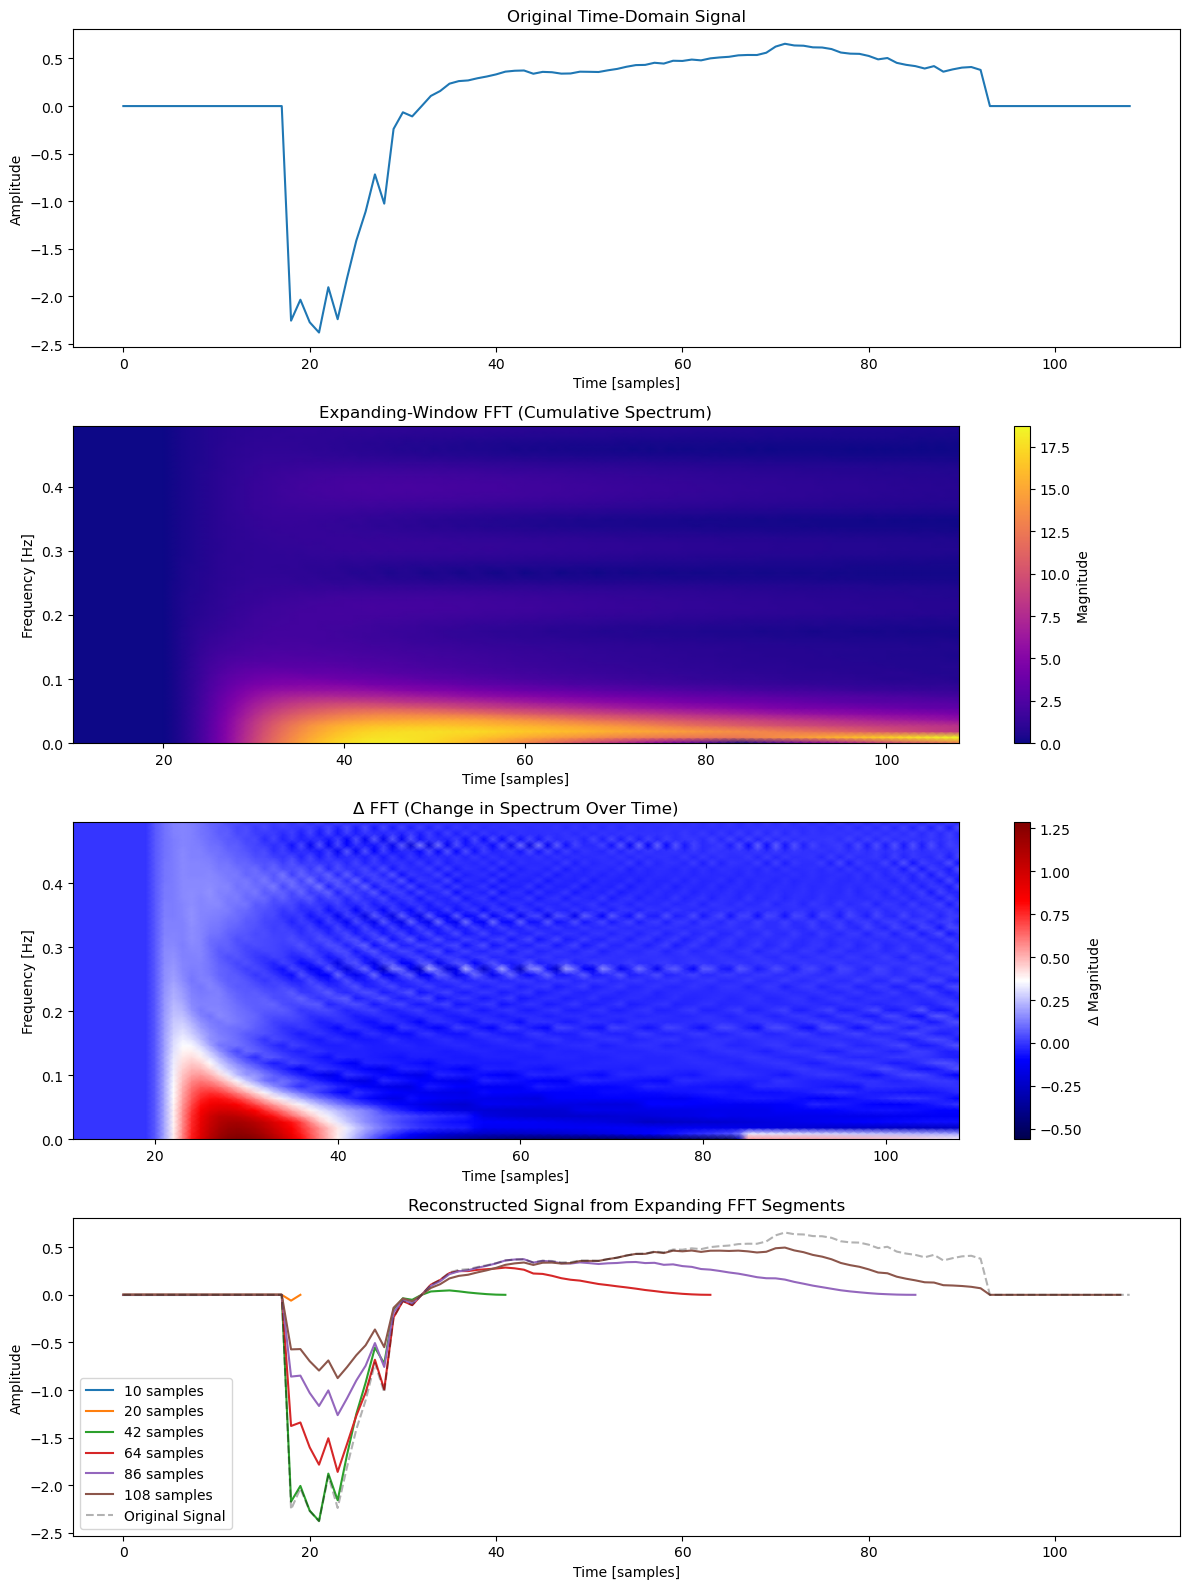

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# --- Extract signal from shot ---
signal = example_shot['equilibrium-triangularity_lower']['values'][0]
T = len(signal)
t = np.arange(T)

# --- FFT parameters ---
min_win = 10   # Minimum FFT window size (samples)
step = 1       # Step size (samples)
fs = 1         # Sample rate (Hz); 1 since sample spacing is uniform
max_len = len(signal)

# --- Containers for results ---
fft_list = []
freqs_list = []
times = []
reconstructed_signals = []

# --- Expanding FFT computation ---
for end in range(min_win, max_len, step):
    segment = signal[:end] * np.hanning(end)  # Apply Hanning window
    fft_vals = np.fft.rfft(segment)
    fft_freqs = np.fft.rfftfreq(end, 1/fs)

    fft_list.append(np.abs(fft_vals))
    freqs_list.append(fft_freqs)
    times.append(end / fs)

    # --- Inverse FFT reconstruction ---
    recon_segment = np.fft.irfft(fft_vals)
    reconstructed_signals.append(recon_segment)

# --- Interpolate FFT to a common frequency grid ---
uniform_freqs = np.fft.rfftfreq(max_len, 1/fs)
interp_spectrogram = []

for fft_vals, f in zip(fft_list, freqs_list):
    interp = np.interp(uniform_freqs, f, fft_vals)
    interp_spectrogram.append(interp)

interp_spectrogram = np.array(interp_spectrogram).T  # Shape: [freqs x times]

# --- Delta (difference between FFTs across time) ---
delta_spectrogram = np.diff(interp_spectrogram, axis=1)
delta_times = times[1:]  # time for delta is 1 shorter


# --- Plotting ---
fig, axs = plt.subplots(4, 1, figsize=(12, 16))

# Plot 1: Original signal
axs[0].plot(t, signal)
axs[0].set_title("Original Time-Domain Signal")
axs[0].set_xlabel("Time [samples]")
axs[0].set_ylabel("Amplitude")

# Plot 2: Expanding FFT spectrum
pcm1 = axs[1].pcolormesh(times, uniform_freqs, interp_spectrogram, shading='gouraud', cmap='plasma')
axs[1].set_title("Expanding-Window FFT (Cumulative Spectrum)")
axs[1].set_xlabel("Time [samples]")
axs[1].set_ylabel("Frequency [Hz]")
axs[1].set_ylim(0, )
fig.colorbar(pcm1, ax=axs[1], label='Magnitude')

# Plot 3: Delta FFT
pcm2 = axs[2].pcolormesh(delta_times, uniform_freqs, delta_spectrogram, shading='gouraud', cmap='seismic')
axs[2].set_title("Δ FFT (Change in Spectrum Over Time)")
axs[2].set_xlabel("Time [samples]")
axs[2].set_ylabel("Frequency [Hz]")
axs[2].set_ylim(0, )
fig.colorbar(pcm2, ax=axs[2], label='Δ Magnitude')

# Plot 4: Reconstructed signals
plot_indices = np.linspace(0, len(reconstructed_signals) - 1, 10).astype(int)
for idx in plot_indices:
    try:
        end = min_win + idx * step
        recon_t = t[:end]
        axs[3].plot(recon_t, reconstructed_signals[idx], label=f'{end} samples')
    except:
        continue

# Overlay original signal
axs[3].plot(t, signal, 'k--', alpha=0.3, label='Original Signal')
axs[3].set_title("Reconstructed Signal from Expanding FFT Segments")
axs[3].set_xlabel("Time [samples]")
axs[3].set_ylabel("Amplitude")
axs[3].legend()

plt.tight_layout()
plt.show()


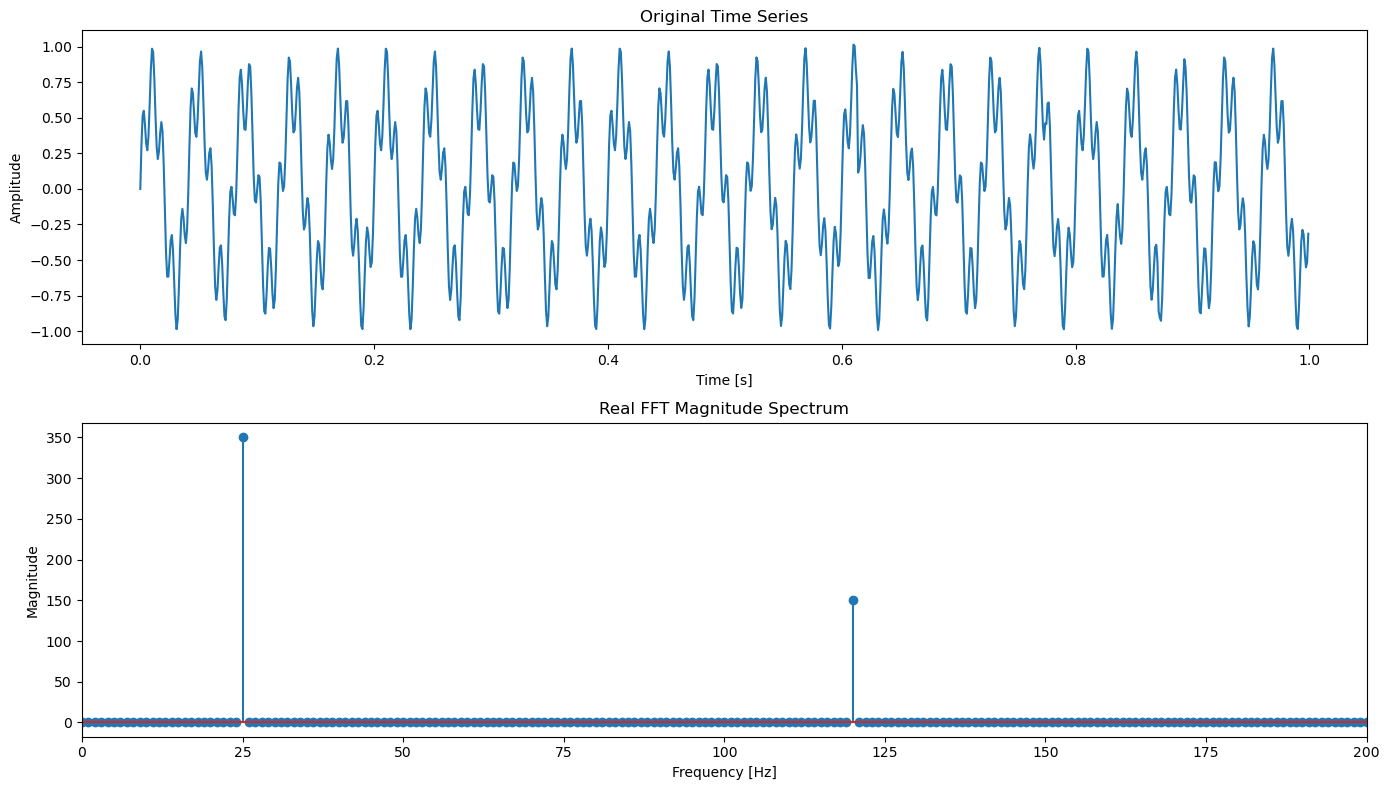

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 1000  # Sampling frequency in Hz
T = 1      # Duration in seconds
t = np.linspace(0, T, int(fs * T), endpoint=False)

# Create a synthetic signal: sum of sine waves
signal = 0.7 * np.sin(2 * np.pi * 25 * t) + 0.3 * np.sin(2 * np.pi * 120 * t) + 0.001* np.tan( ((1+t)/(1-t) ) * t**2 )
# signal = 0.7 * np.sin(2 * np.pi * 25 * t) + 0.3 * np.sin(2 * np.pi * 120 * t) 


# Real FFT
fft_vals = np.fft.rfft(signal)
fft_freqs = np.fft.rfftfreq(len(t), d=1/fs)

# Plot original signal
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title("Original Time Series")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

# Plot magnitude spectrum
plt.subplot(2, 1, 2)
plt.stem(fft_freqs, np.abs(fft_vals))
plt.title("Real FFT Magnitude Spectrum")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.xlim(0, 200)
plt.tight_layout()
plt.show()


/var/folders/0s/09_rjjs504vdtfg7jr_4t7k00000gn/T/ipykernel_43789/246649245.py:13: RuntimeWarning: divide by zero encountered in divide
  lambda t: 0.7 * np.sin(2*np.pi*120*t)* 0.7 * np.sin(2 * np.pi * 25 * t) + 0.3 * np.sin(2 * np.pi * 120 * t) + 0.001* np.tan( ((1+t)/(1-t) ) * t**2 )])
/var/folders/0s/09_rjjs504vdtfg7jr_4t7k00000gn/T/ipykernel_43789/246649245.py:13: RuntimeWarning: invalid value encountered in tan
  lambda t: 0.7 * np.sin(2*np.pi*120*t)* 0.7 * np.sin(2 * np.pi * 25 * t) + 0.3 * np.sin(2 * np.pi * 120 * t) + 0.001* np.tan( ((1+t)/(1-t) ) * t**2 )])


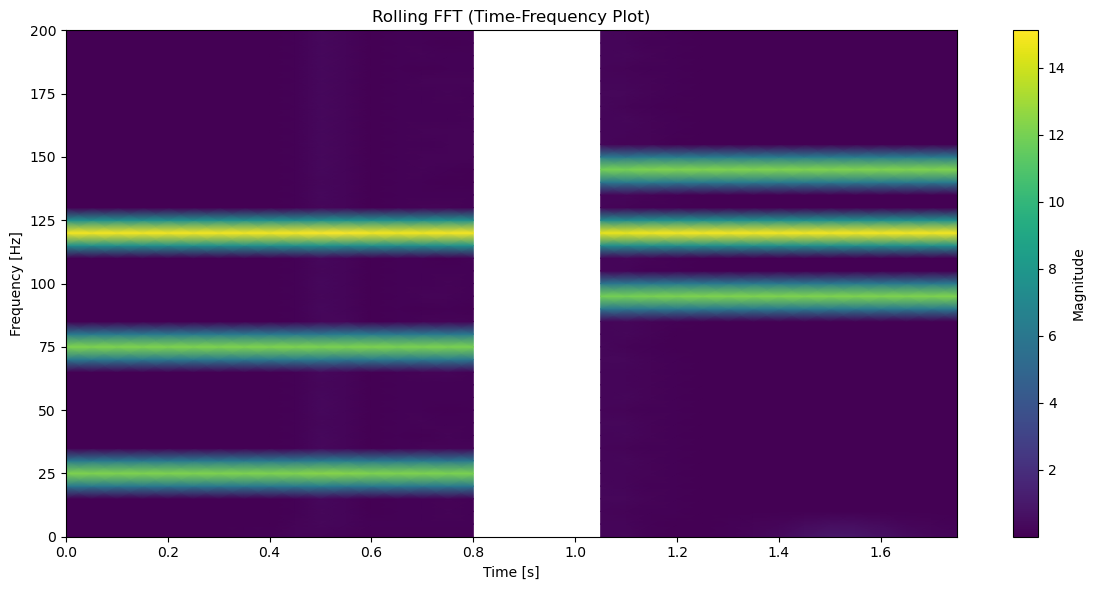

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic signal: two sinusoids at different times
fs = 1000  # Sampling rate
T = 2      # Total duration
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Time-varying signal: 50 Hz in first half, 120 Hz in second half
signal = np.piecewise(t, 
                      [t < T/2, t >= T/2], 
                      [lambda t: 0.7 * np.sin(2*np.pi*50*t)* 0.7 * np.sin(2 * np.pi * 25 * t) + 0.3 * np.sin(2 * np.pi * 120 * t) + 0.001* np.tan( ((1+t)/(1-t) ) * t**2 ), 
                       lambda t: 0.7 * np.sin(2*np.pi*120*t)* 0.7 * np.sin(2 * np.pi * 25 * t) + 0.3 * np.sin(2 * np.pi * 120 * t) + 0.001* np.tan( ((1+t)/(1-t) ) * t**2 )])

# Rolling window FFT settings
win_size = int(0.2 * fs)  # 200 ms window
step_size = int(0.05 * fs)  # 50 ms step
n_windows = (len(signal) - win_size) // step_size

# Frequency axis
freqs = np.fft.rfftfreq(win_size, 1/fs)
spectrogram = []

# Compute FFT for each window
for i in range(n_windows):
    start = i * step_size
    end = start + win_size
    window = signal[start:end] * np.hanning(win_size)  # apply window function
    fft_vals = np.abs(np.fft.rfft(window))
    spectrogram.append(fft_vals)

spectrogram = np.array(spectrogram).T  # shape: [freqs x time]

# Time axis for rolling windows
times = np.arange(n_windows) * step_size / fs

# Plot as spectrogram
plt.figure(figsize=(12, 6))
plt.pcolormesh(times, freqs, spectrogram, shading='gouraud', cmap='viridis')
plt.colorbar(label='Magnitude')
plt.title("Rolling FFT (Time-Frequency Plot)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.ylim(0, 200)
plt.tight_layout()
plt.show()


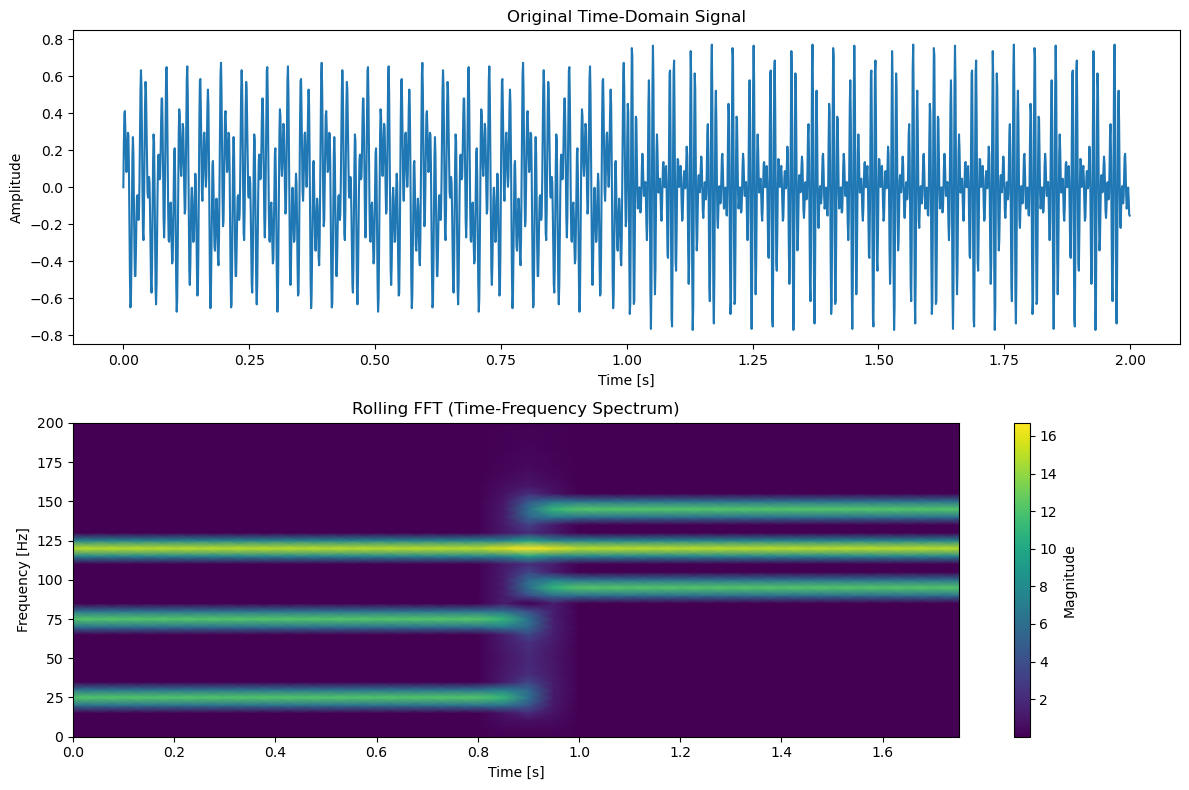

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generate synthetic signal ---
fs = 1000  # Sampling rate (Hz)
T = 2      # Duration (seconds)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Time-varying signal: 50 Hz for first half, 120 Hz for second half
signal = np.piecewise(t, 
                      [t < T/2, t >= T/2], 
                      [lambda t: 0.7 * np.sin(2*np.pi*50*t)* 0.7 * np.sin(2 * np.pi * 25 * t) + 0.3 * np.sin(2 * np.pi * 120 * t) , 
                       lambda t: 0.7 * np.sin(2*np.pi*120*t)* 0.7 * np.sin(2 * np.pi * 25 * t) + 0.3 * np.sin(2 * np.pi * 120 * t) ])


# --- Rolling FFT settings ---
win_size = int(0.2 * fs)     # 200 ms window
step_size = int(0.05 * fs)   # 50 ms step
n_windows = (len(signal) - win_size) // step_size

freqs = np.fft.rfftfreq(win_size, 1/fs)
spectrogram = []

for i in range(n_windows):
    start = i * step_size
    end = start + win_size
    window = signal[start:end] * np.hanning(win_size)
    fft_vals = np.abs(np.fft.rfft(window))
    spectrogram.append(fft_vals)

spectrogram = np.array(spectrogram).T  # shape: [freqs x time]
times = np.arange(n_windows) * step_size / fs  # time axis

# --- Plotting ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# 1. Plot original time-domain signal
axs[0].plot(t, signal)
axs[0].set_title("Original Time-Domain Signal")
axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel("Amplitude")

# 2. Plot rolling FFT as spectrogram
pcm = axs[1].pcolormesh(times, freqs, spectrogram, shading='gouraud', cmap='viridis')
axs[1].set_title("Rolling FFT (Time-Frequency Spectrum)")
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("Frequency [Hz]")
axs[1].set_ylim(0, 200)
fig.colorbar(pcm, ax=axs[1], label='Magnitude')

plt.tight_layout()
plt.show()


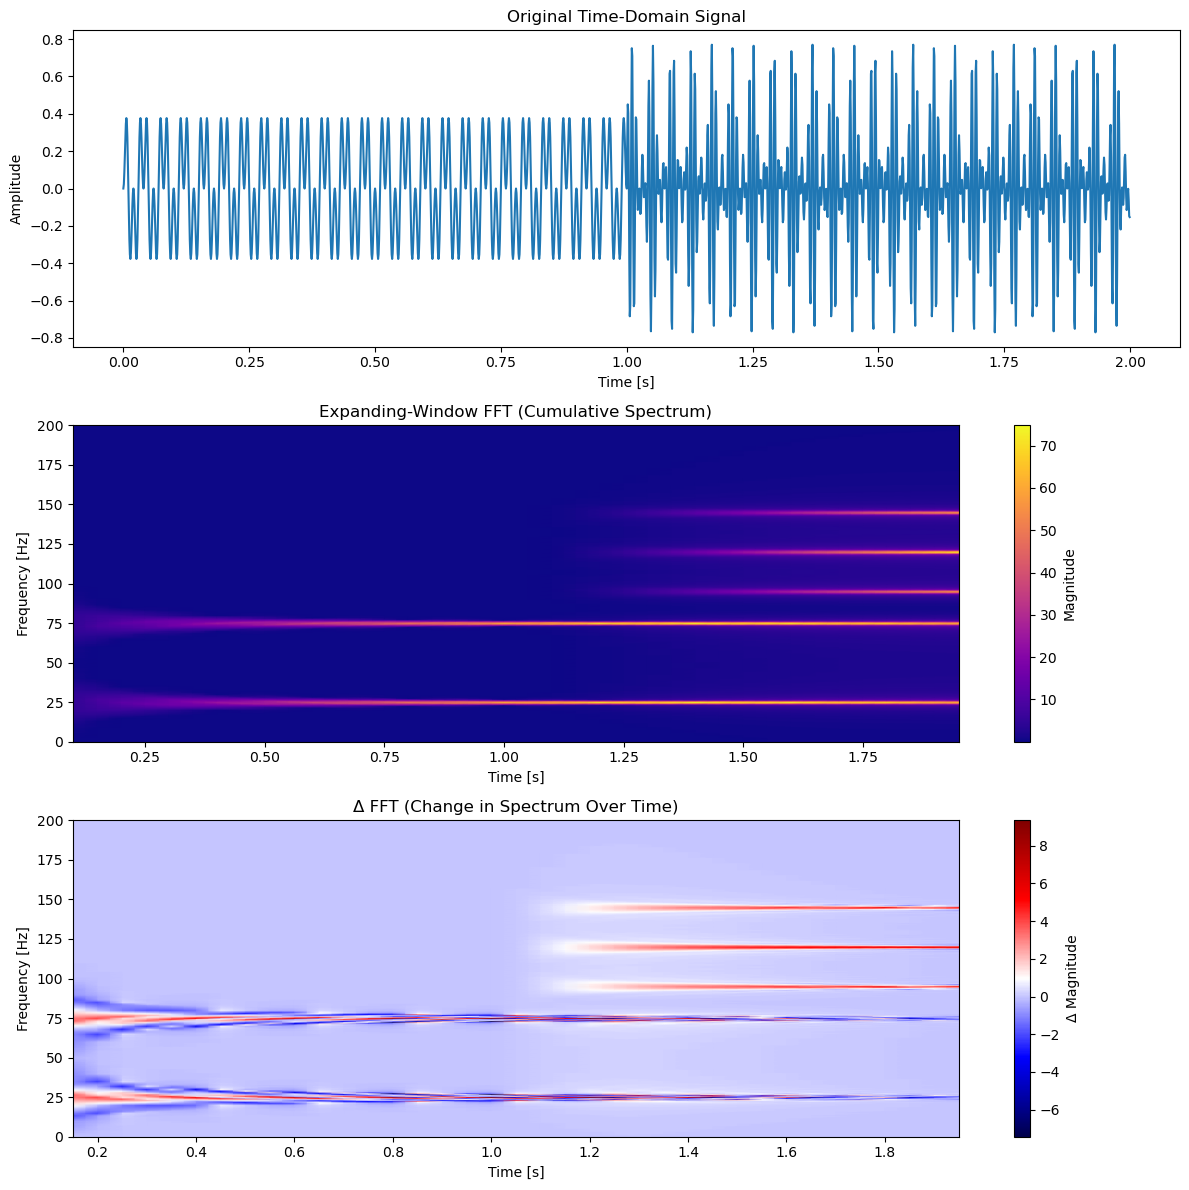

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generate synthetic signal ---
fs = 1000  # Sampling rate (Hz)
T = 2      # Duration (seconds)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Construct complex time-varying signal
signal = np.piecewise(
    t,
    [t < T/2, t >= T/2],
    [
        lambda t: 0.7 * np.sin(2*np.pi*50*t)* 0.7 * np.sin(2*np.pi*25*t) ,
        lambda t: 0.7 * np.sin(2*np.pi*120*t)* 0.7 * np.sin(2*np.pi*25*t) + 0.3 * np.sin(2*np.pi*120*t)
    ]
)

# --- Expanding FFT settings ---
min_win = int(0.1 * fs)  # start at 100 ms
step = int(0.05 * fs)    # grow by 50 ms each step
max_len = len(signal)

fft_list = []
freqs_list = []
times = []

for end in range(min_win, max_len, step):
    segment = signal[:end] * np.hanning(end)
    fft_vals = np.abs(np.fft.rfft(segment))
    fft_freqs = np.fft.rfftfreq(end, 1/fs)

    fft_list.append(fft_vals)
    freqs_list.append(fft_freqs)
    times.append(end / fs)

# Interpolate to uniform frequency axis for plotting
max_len_freq = max(len(f) for f in fft_list)
uniform_freqs = np.fft.rfftfreq(max_len, 1/fs)
interp_spectrogram = []

for fft_vals, f in zip(fft_list, freqs_list):
    interp = np.interp(uniform_freqs, f, fft_vals)
    interp_spectrogram.append(interp)

interp_spectrogram = np.array(interp_spectrogram).T  # shape: [freqs x time]

# Compute delta between FFTs across time (difference along columns)
delta_spectrogram = np.diff(interp_spectrogram, axis=1)
delta_times = times[1:]  # since diff drops one time step



# 3. Plot delta of expanding FFTs
fig, axs = plt.subplots(3, 1, figsize=(12, 12))

# Plot 1: Original signal
axs[0].plot(t, signal)
axs[0].set_title("Original Time-Domain Signal")
axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel("Amplitude")

# Plot 2: Expanding FFT
pcm1 = axs[1].pcolormesh(times, uniform_freqs, interp_spectrogram, shading='gouraud', cmap='plasma')
axs[1].set_title("Expanding-Window FFT (Cumulative Spectrum)")
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("Frequency [Hz]")
axs[1].set_ylim(0, 200)
fig.colorbar(pcm1, ax=axs[1], label='Magnitude')

# Plot 3: Delta of expanding FFT
pcm2 = axs[2].pcolormesh(delta_times, uniform_freqs, delta_spectrogram, shading='gouraud', cmap='seismic')
axs[2].set_title("Δ FFT (Change in Spectrum Over Time)")
axs[2].set_xlabel("Time [s]")
axs[2].set_ylabel("Frequency [Hz]")
axs[2].set_ylim(0, 200)
fig.colorbar(pcm2, ax=axs[2], label='Δ Magnitude')

plt.tight_layout()
plt.show()



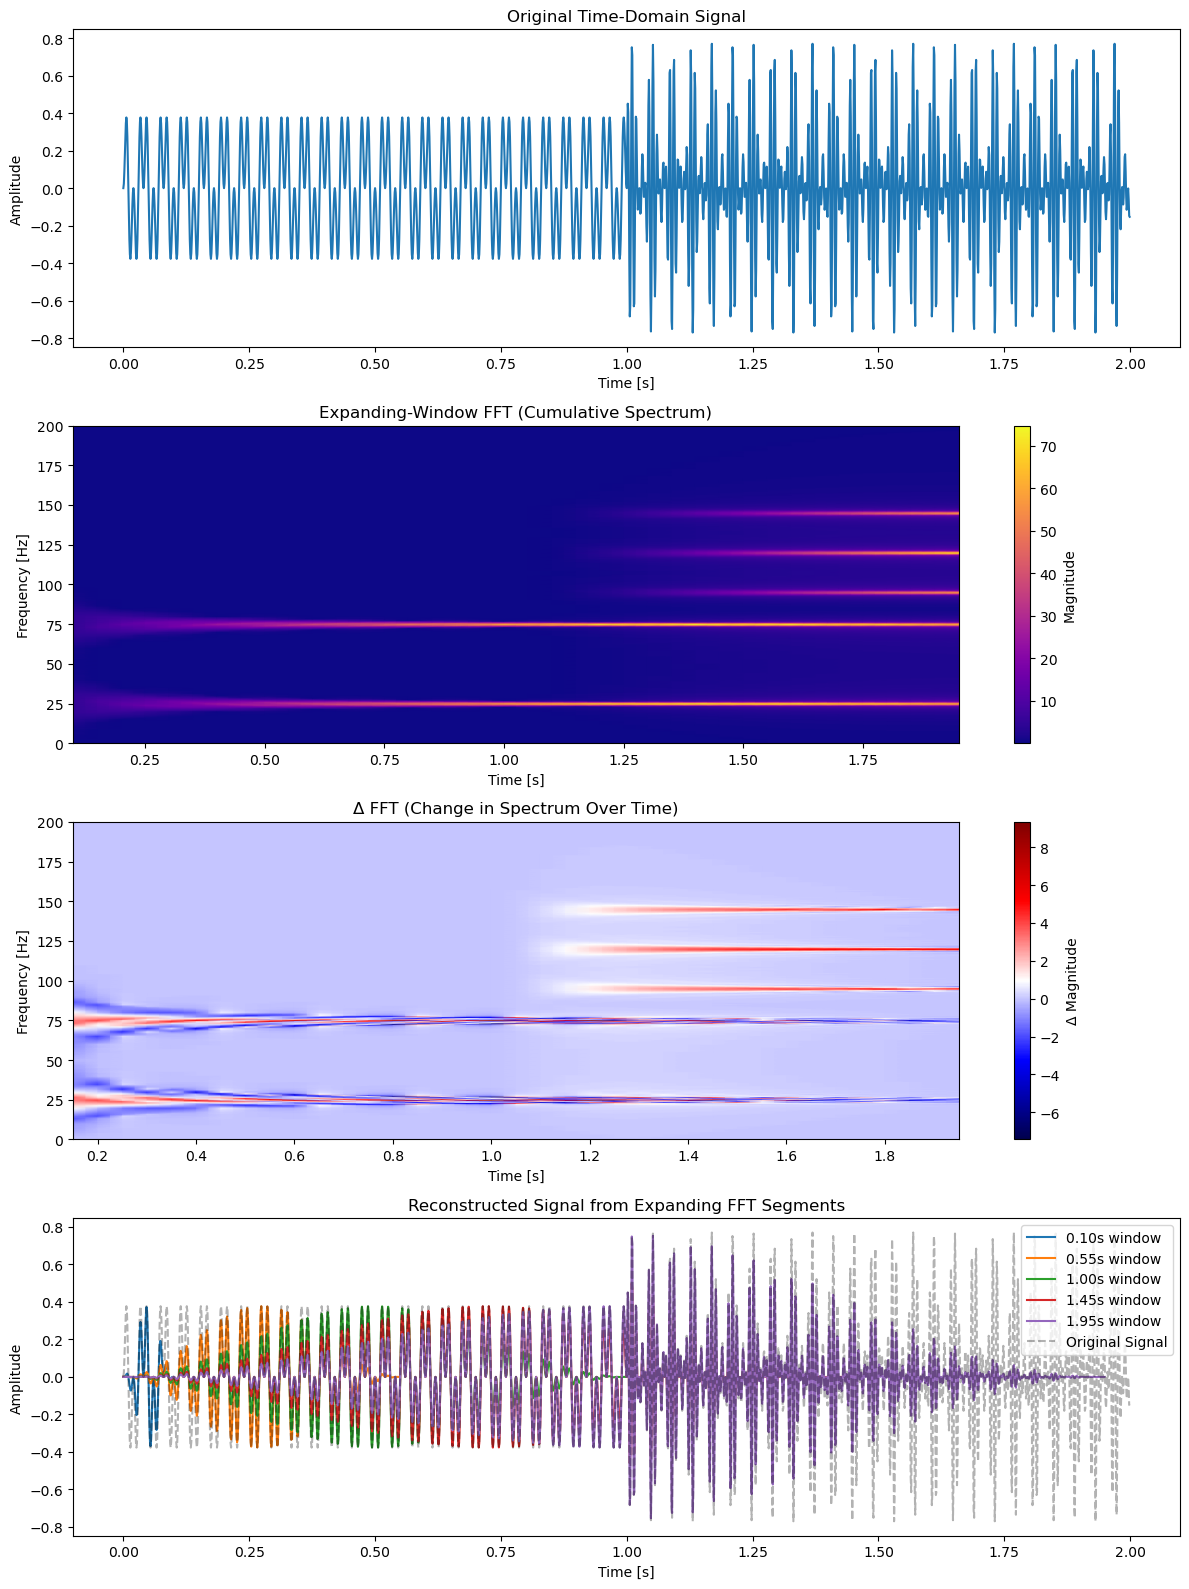

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# --- Generate synthetic signal ---
fs = 1000  # Sampling rate (Hz)
T = 2      # Duration (seconds)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Construct complex time-varying signal
signal = np.piecewise(
    t,
    [t < T/2, t >= T/2],
    [
        lambda t: 0.7 * np.sin(2*np.pi*50*t)* 0.7 * np.sin(2*np.pi*25*t) ,
        lambda t: 0.7 * np.sin(2*np.pi*120*t)* 0.7 * np.sin(2*np.pi*25*t) + 0.3 * np.sin(2*np.pi*120*t)
    ]
)

# --- Expanding FFT settings ---
min_win = int(0.1 * fs)  # start at 100 ms
step = int(0.05 * fs)    # grow by 50 ms each step
max_len = len(signal)

fft_list = []
freqs_list = []
times = []
reconstructed_signals = []

for end in range(min_win, max_len, step):
    segment = signal[:end] * np.hanning(end)
    fft_vals = np.fft.rfft(segment)
    fft_freqs = np.fft.rfftfreq(end, 1/fs)

    fft_list.append(np.abs(fft_vals))
    freqs_list.append(fft_freqs)
    times.append(end / fs)
    
    # --- Reconstruct signal via inverse FFT ---
    recon_segment = np.fft.irfft(fft_vals)
    # recon_segment length matches segment length 'end'
    reconstructed_signals.append(recon_segment)

# Interpolate to uniform frequency axis for plotting FFT magnitude (existing code)
max_len_freq = max(len(f) for f in fft_list)
uniform_freqs = np.fft.rfftfreq(max_len, 1/fs)
interp_spectrogram = []

for fft_vals_abs, f in zip(fft_list, freqs_list):
    interp = np.interp(uniform_freqs, f, fft_vals_abs)
    interp_spectrogram.append(interp)

interp_spectrogram = np.array(interp_spectrogram).T  # shape: [freqs x time]

# Compute delta between FFTs across time (difference along columns)
delta_spectrogram = np.diff(interp_spectrogram, axis=1)
delta_times = times[1:]  # since diff drops one time step

# --- Plotting ---

fig, axs = plt.subplots(4, 1, figsize=(12, 16))

# Plot 1: Original signal
axs[0].plot(t, signal)
axs[0].set_title("Original Time-Domain Signal")
axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel("Amplitude")

# Plot 2: Expanding FFT magnitude
pcm1 = axs[1].pcolormesh(times, uniform_freqs, interp_spectrogram, shading='gouraud', cmap='plasma')
axs[1].set_title("Expanding-Window FFT (Cumulative Spectrum)")
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("Frequency [Hz]")
axs[1].set_ylim(0, 200)
fig.colorbar(pcm1, ax=axs[1], label='Magnitude')

# Plot 3: Delta of expanding FFT
pcm2 = axs[2].pcolormesh(delta_times, uniform_freqs, delta_spectrogram, shading='gouraud', cmap='seismic')
axs[2].set_title("Δ FFT (Change in Spectrum Over Time)")
axs[2].set_xlabel("Time [s]")
axs[2].set_ylabel("Frequency [Hz]")
axs[2].set_ylim(0, 200)
fig.colorbar(pcm2, ax=axs[2], label='Δ Magnitude')

# Plot 4: Reconstructed signals from expanding FFT
# For clarity, plot a few reconstructed segments spaced out
plot_indices = np.linspace(0, len(reconstructed_signals)-1, 5).astype(int)

for idx in plot_indices:
    end = min_win + idx * step
    recon_t = np.linspace(0, end/fs, end, endpoint=False)
    axs[3].plot(recon_t, reconstructed_signals[idx], label=f'{end/fs:.2f}s window')

axs[3].plot(t, signal, 'k--', alpha=0.3, label='Original Signal')
axs[3].set_title("Reconstructed Signal from Expanding FFT Segments")
axs[3].set_xlabel("Time [s]")
axs[3].set_ylabel("Amplitude")
axs[3].legend()

plt.tight_layout()
plt.show()
